In [ ]:
from process_ab_compartments import query_compartment
from methylseqnet.dataset import BaseHDF5Dataset
from methylseqnet.peaks import selected_peaks_from_target
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import torch
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from collections import defaultdict
import pysam
from methylseqnet_repro.paths import configs, atac_atlas, methylation_atlas, preprocessed_datasets, annotations, analysis_pickles
from methylseqnet.metrics import delta_z
from mpl_toolkits.axes_grid1 import make_axes_locatable
from adjustText import adjust_text
import h5py
import pickle
import statsmodels.api as sm

/clusterfs/nilah/oberon/environments/methylseqnet/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Lifting over coordinates using /clusterfs/nilah/oberon/genomes/hg19ToHg38.over.chain.gz ...
  Liftover: kept 2779/2779 bins (2779 rows)
       chr      start        end GM12878 H1-hESC IMR90  MES MSC  NPC  TRO  \
0     chr1    1064621    2068561     NaN       A     A  NaN   A  NaN  NaN   
1     chr1    2068562    3083436       A       A     A    A   B  NaN    A   
2     chr1    3083437    3939940       A       A     B    A   B  NaN    A   
3     chr1    3939941    4939940       A       A     B    A   B    A    A   
4     chr1    4939941    5939940       A       A     B    A   B    A    B   
...    ...        ...        ...     ...     ...   ...  ...  ..  ...  ...   
2774  chrX  150831528  151831528       A       A     B    A   B    A    B   
2775  chrX  151831529  152831456       B       A     B    A   B  NaN    B   
2776  chrX  152831457  153734546       A       A     A    A   A  NaN    A   
2777  chrX  153734547  154771725       A     NaN     A  NaN   A  NaN  NaN   
2778  chrX  15477

In [2]:
atlas_parent_folder = preprocessed_datasets
methylation_parent_folder = methylation_atlas
atlas_folder = atlas_parent_folder / "atlas"
methylation_depth_path = annotations / "41586_2022_5580_MOESM4_ESM.xlsx" #methylation_parent_folder / 
def parse_region(region_str):
    """Parse chr5:41462305-41986593 format"""
    chrom, coords = region_str.split(':')
    start, end = map(int, coords.split('-'))
    return chrom, start, end
chr_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
chr_lengths = {
    'chr1': 248956422, 'chr2': 242193529, 'chr3': 198295559,
    'chr4': 190214555, 'chr5': 181538259, 'chr6': 170805979,
    'chr7': 159345973, 'chr8': 145138636, 'chr9': 138394717,
    'chr10': 133797422, 'chr11': 135086622, 'chr12': 133275309,
    'chr13': 114364328, 'chr14': 107043718, 'chr15': 101991189,
    'chr16': 90338345, 'chr17': 83257441, 'chr18': 80373285,
    'chr19': 58617616, 'chr20': 64444167, 'chr21': 46709983,
    'chr22': 50818468, 'chrX': 156040895
}
def merge_intervals(intervals):
    """Merge overlapping intervals to get true coverage"""
    if not intervals:
        return []
    
    # Sort by start position
    intervals = sorted(intervals, key=lambda x: x[0])
    merged = [intervals[0]]
    
    for current in intervals[1:]:
        last = merged[-1]
        if current[0] <= last[1]:  # Overlapping
            merged[-1] = (last[0], max(last[1], current[1]))
        else:
            merged.append(current)
    
    return merged
def has_stretch_enhancer(chrom, pos, tabix_file):
    """
    Check if a genomic position overlaps any stretch enhancer.
    
    Args:
        chrom: chromosome (e.g., 'chr1')
        pos: position (0-based)
        tabix_file: pysam.TabixFile object
    
    Returns:
        bool: True if position overlaps at least one stretch enhancer
    """
    try:
        # Query a 1bp region [pos, pos+1)
        overlaps = list(tabix_file.fetch(chrom, pos, pos + 1))
        return len(overlaps) > 0
    except:
        return False
def rowwise_corrcoef(X, y):
    # Center
    X_c = X - X.mean(axis=1, keepdims=True)
    y_c = y - y.mean()
    # Correlations
    num = X_c @ y_c
    denom = np.sqrt((X_c**2).sum(axis=1) * (y_c**2).sum())
    return num / denom

In [3]:
model_pairs = [
    ("slurm32260895task0/fold3", "slurm32260895task1/fold3"),
    ("slurm32260895task8/fold3", "slurm32260895task9/fold3"),
]

In [ ]:
max_samples = None
cell_type_tsv = configs / 'cell_type_matching_atac-cage.tsv'
cell_type_df = pd.read_csv(cell_type_tsv, sep='\t')
cell_type_methyl_to_atac_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['ATAC_Match_Quality']))
cell_type_methyl_to_cage_quality = dict(zip(cell_type_df['Methylation_Atlas'], cell_type_df['CAGE_Match_Quality']))
methyl_atlas_df = pd.read_excel(
    methylation_depth_path,
    sheet_name="Table S1",
    header=2,
)
cell_type_methyl_to_read_depth = dict([
    (
        methyl_cell_type,
        methyl_atlas_df[methyl_atlas_df['Sample name'].str.contains(methyl_cell_type)]['CpG coverage (fragments)'].sum())
    for methyl_cell_type in cell_type_df['Methylation_Atlas']
])
min_bin_counts_crosstask = {
    'atac': 15,
    'cage': 40,
}
min_bin_counts_crossbin = {
    'atac': 0,
    'cage': 0,
}
bin_size = 128

celltype_names = defaultdict(dict)
match_qualities = defaultdict(lambda: defaultdict(list))
methyl_read_depth = defaultdict(lambda: defaultdict(list))

pearson_per_track = defaultdict(dict)
pearson_per_track_delta = defaultdict(dict)
pearson_per_bin = defaultdict(dict)
high_count_targets = defaultdict(dict)
high_count_predictions = defaultdict(dict)
high_count_loci_by_model = defaultdict(dict)

for model_pair in model_pairs:
    for model_idx, model_identifier in enumerate(model_pair):
        print(f"Processing dataset {model_identifier}")
        dataset_path = atlas_folder / model_identifier / "predictions.h5"
        dataset = BaseHDF5Dataset(dataset_path)
        io_mappings_df = dataset.get_io_mappings_df()
        atac_channels = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq']['channel'].tolist()
        atac_df = io_mappings_df[io_mappings_df['data_type']=='ATAC-seq'].copy()
        celltype_names[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").tolist()
        match_qualities[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_atac_quality).tolist()
        methyl_read_depth[model_identifier]['atac'] = atac_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_read_depth).tolist()
        cage_channels = io_mappings_df[io_mappings_df['data_type']=='CAGE-seq']['channel'].tolist()
        cage_df = io_mappings_df[io_mappings_df['data_type']=='CAGE-seq'].copy()
        celltype_names[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").tolist()
        match_qualities[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_cage_quality).tolist()
        methyl_read_depth[model_identifier]['cage'] = cage_df['methylation_files'].str.strip("[]'").map(cell_type_methyl_to_read_depth).tolist()
        with h5py.File(dataset_path, 'r') as f:
            target_samples = torch.tensor(f['tracks'][0:max_samples,:] if max_samples is not None else f['tracks'][:])
            prediction_samples = torch.tensor(f['predictions'][0:max_samples,:] if max_samples is not None else f['predictions'][:])
            regions_list = [region_str.decode('utf8').split('|')[0] for region_str in f['specifier'][0:max_samples]]
        all_targets = target_samples.permute(2, 1, 3, 0).reshape(target_samples.shape[2], -1)
        all_predictions = prediction_samples.permute(2, 1, 3, 0).reshape(prediction_samples.shape[2], -1)
        for channels, label in [(atac_channels, 'atac'), (cage_channels, 'cage')]:
            targets = np.array(all_targets[channels,:])
            predictions = np.array(all_predictions[channels,:])
            mean_targets_by_bin = np.mean(targets, axis=0)
            mean_predictions_by_bin = np.mean(predictions, axis=0)
            high_counts_indices = selected_peaks_from_target(
                target = targets.max(axis=0),
                peak_threshold = min_bin_counts_crosstask[label],
                min_peak_distance_bins = 8,
                )
            target_values_high_counts = targets[:,high_counts_indices]
            prediction_values_high_counts = predictions[:,high_counts_indices]

            delta_from_mean_targets = targets - mean_targets_by_bin[np.newaxis, :]
            delta_from_mean_predictions = predictions - mean_predictions_by_bin[np.newaxis, :]
            bins_per_region = targets.shape[1] // len(regions_list)

            high_count_loci = []
            pearson_corrs_taskwise = []
            pearson_corrs = []
            pearson_corrs_delta = []

            for bin_index in high_counts_indices:
                region_index = bin_index // bins_per_region
                bins_subindex = bin_index % bins_per_region
                try:
                    region_chrom = regions_list[region_index].split(':')[0]
                    region_start = int(regions_list[region_index].split(':')[1].split('-')[0])
                    region_end = int(regions_list[region_index].split(':')[1].split('-')[1])
                    region_with_labels = bins_per_region * bin_size
                    high_count_locus = (region_chrom,int((region_start + region_end)//2 - region_with_labels//2 + (bins_subindex+0.5)*bin_size))
                    high_count_loci.append(high_count_locus)
                except:
                    high_count_loci.append(('none',-1))
                pearson_corrs_taskwise.append(pearsonr(targets[:,bin_index], predictions[:,bin_index])[0])
            for track_idx in range(targets.shape[0]):
                pearson_corrs.append(pearsonr(targets[track_idx], predictions[track_idx])[0])
                pearson_corrs_delta.append(pearsonr(delta_from_mean_targets[track_idx,high_counts_indices], delta_from_mean_predictions[track_idx,high_counts_indices])[0])

            pearson_per_track[model_identifier][label] = pearson_corrs
            pearson_per_track_delta[model_identifier][label] = pearson_corrs_delta
            pearson_per_bin[model_identifier][label] = pearson_corrs_taskwise
            high_count_targets[model_identifier][label] = target_values_high_counts
            high_count_predictions[model_identifier][label] = prediction_values_high_counts
            high_count_loci_by_model[model_identifier][label] = high_count_loci


In [5]:
# with open(analysis_pickles / 'optimized_cell_type_results.pkl', 'wb') as f:
#     pickle.dump({
#         'pearson_per_track': dict(pearson_per_track),
#         'pearson_per_track_delta': dict(pearson_per_track_delta),
#         'pearson_per_bin': dict(pearson_per_bin),
#         'high_count_targets': dict(high_count_targets),
#         'high_count_predictions': dict(high_count_predictions),
#         'celltype_names': dict(celltype_names),
#         'match_qualities': dict(match_qualities),
#         'methyl_read_depth': dict(methyl_read_depth),
#         'high_count_loci_by_model': dict(high_count_loci_by_model),
#     }, f)

# Load
with open(analysis_pickles / 'optimized_cell_type_results.pkl', 'rb') as f:
    results = pickle.load(f)

pearson_per_track = defaultdict(dict, results['pearson_per_track'])
pearson_per_track_delta = defaultdict(dict, results['pearson_per_track_delta'])
pearson_per_bin = defaultdict(dict, results['pearson_per_bin'])
high_count_targets = defaultdict(dict, results['high_count_targets'])
high_count_predictions = defaultdict(dict, results['high_count_predictions'])
celltype_names = defaultdict(dict, results['celltype_names'])
match_qualities = defaultdict(lambda: defaultdict(list), results['match_qualities'])
methyl_read_depth = defaultdict(lambda: defaultdict(list), results['methyl_read_depth'])
high_count_loci_by_model = defaultdict(dict, results['high_count_loci_by_model'])

/tmp/ipykernel_1044302/1732445887.py:128: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(plot_size+cbar_extra, plot_size))


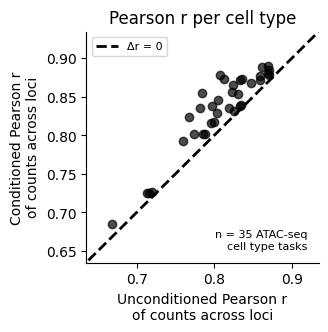

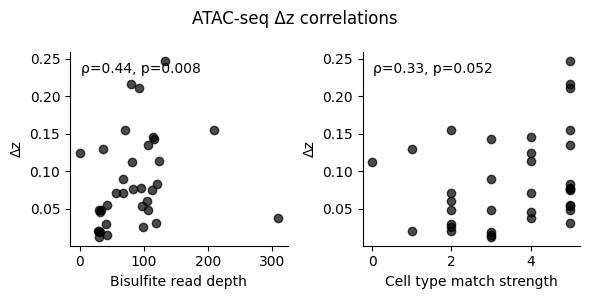

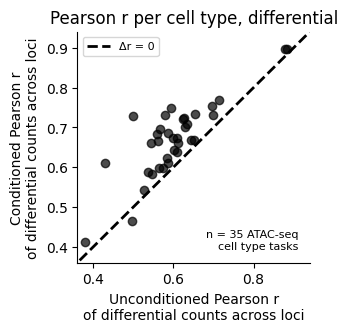

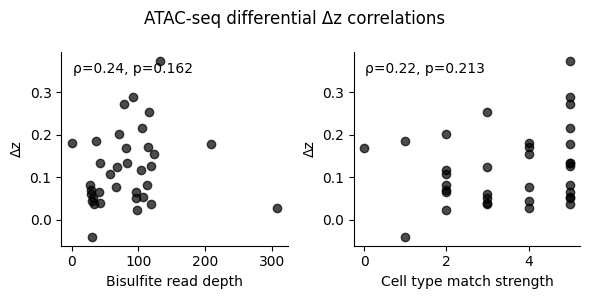

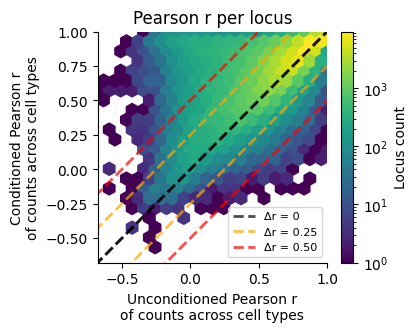

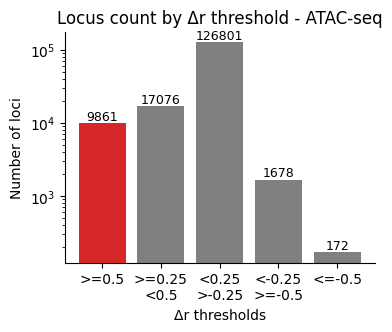

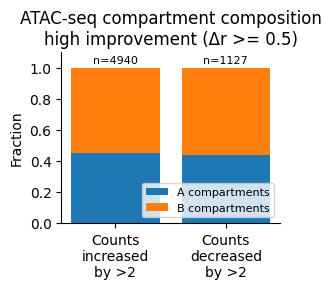

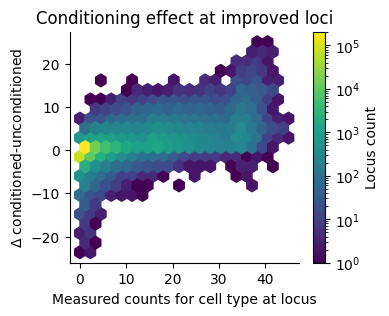

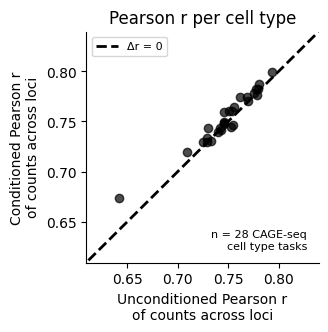

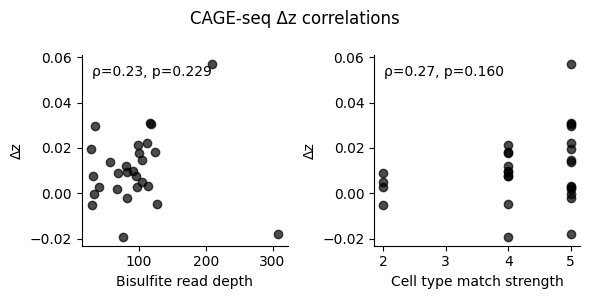

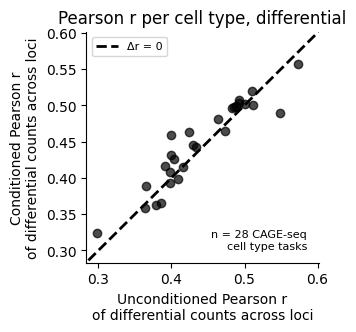

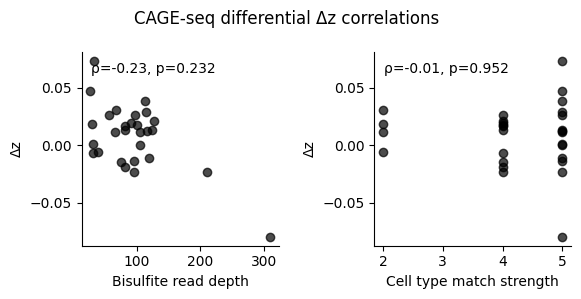

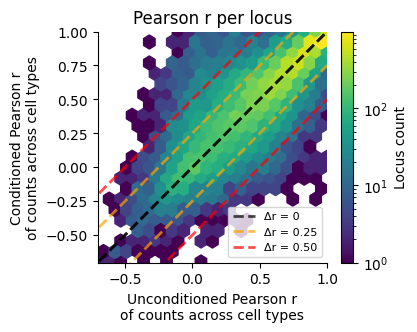

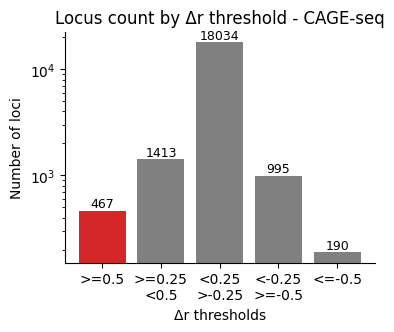

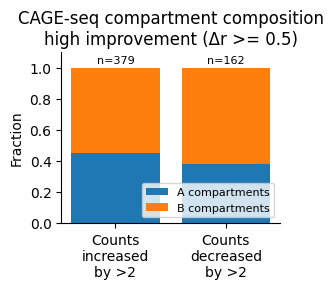

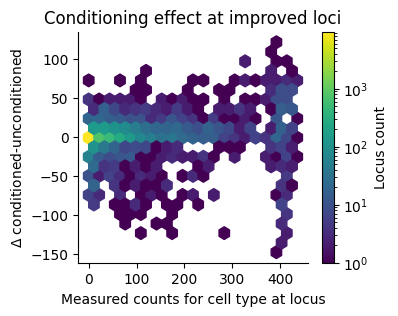

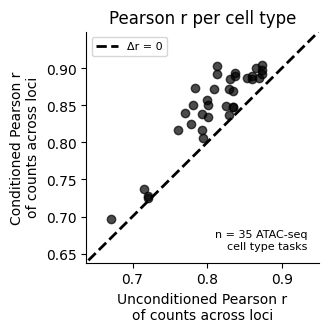

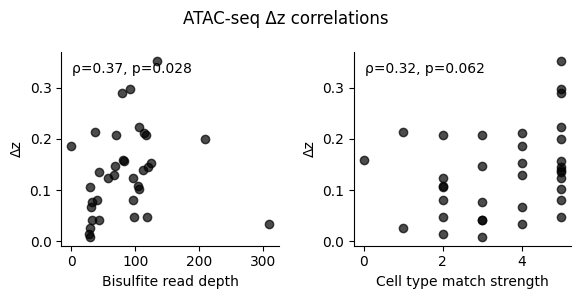

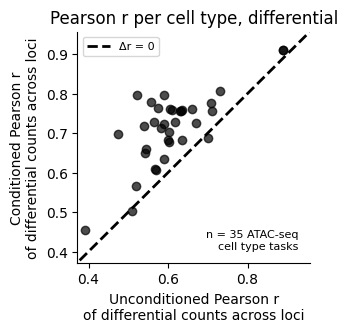

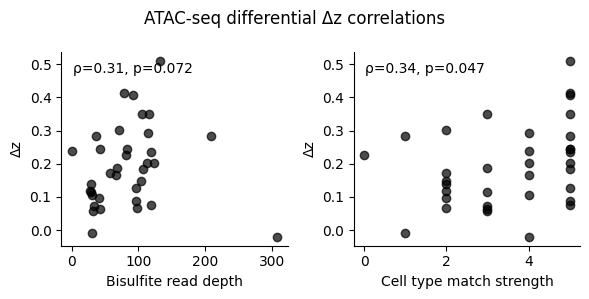

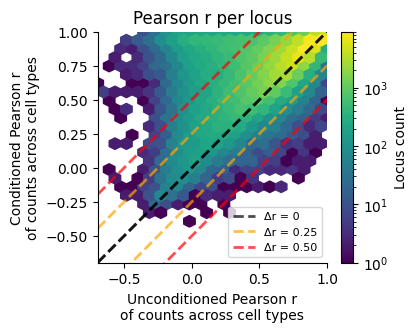

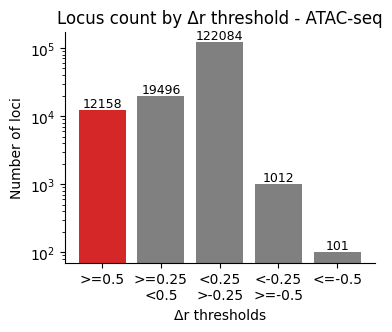

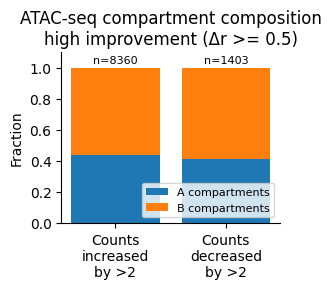

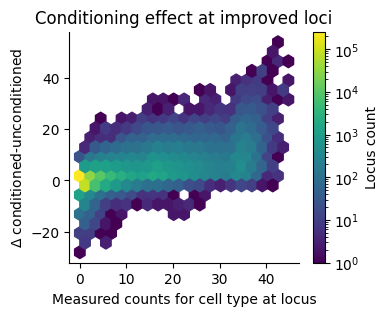

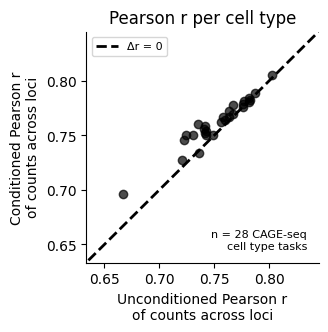

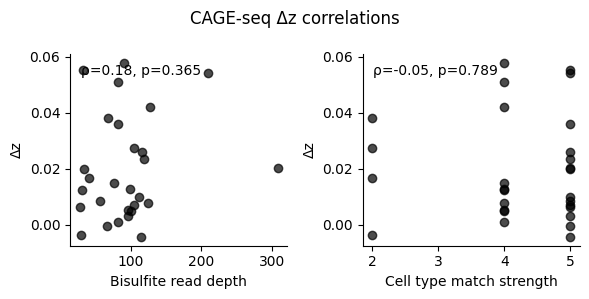

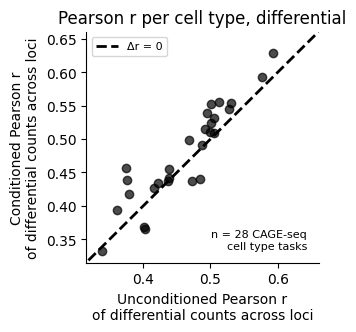

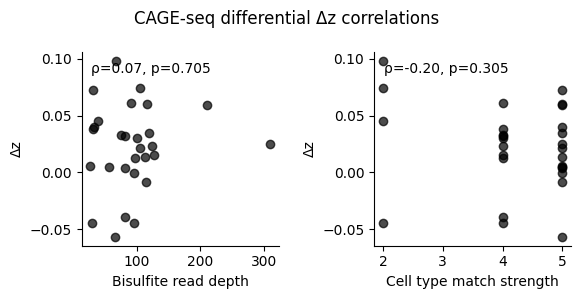

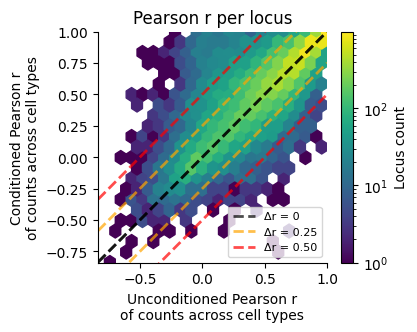

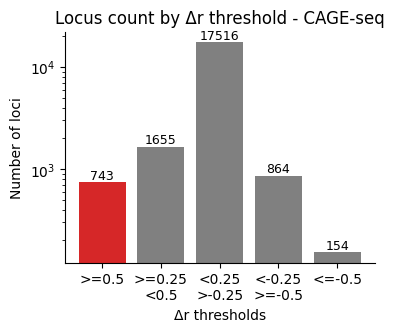

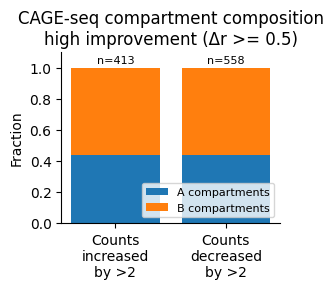

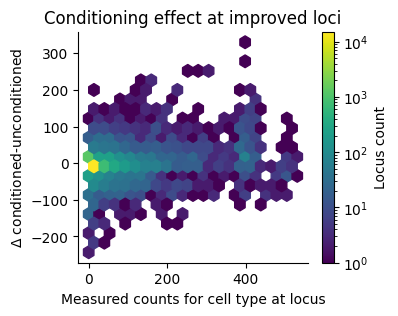

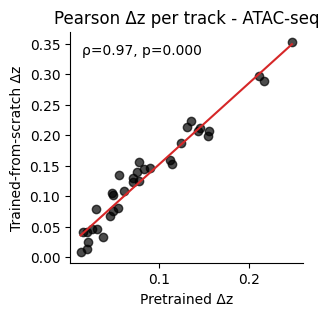

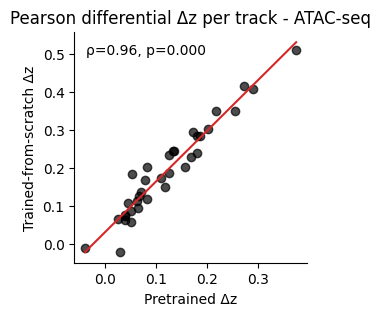

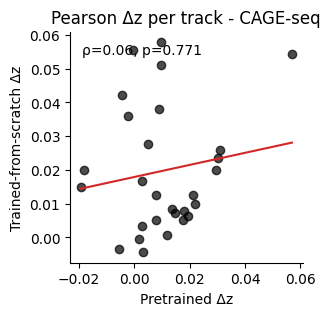

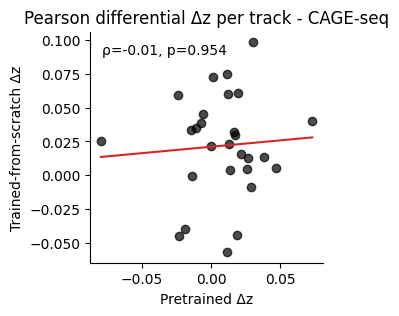

In [6]:
plot_size = 3
cbar_extra = 0.7
high_delta_threshold = 0.5
low_delta_threshold = 0.25
axis_past_points = 0.05
pearson_improvements_by_celltype = defaultdict(dict)
pearson_delta_improvements_by_celltype = defaultdict(dict)
for model_pair_idx, model_pair in enumerate(model_pairs):
    # Compare the two models
    for data_type in ['atac', 'cage']:
        scatter_fig_type = "cell_types__" if (model_pair_idx == 0 and data_type=='atac') else "supplement__"
        methyl_read_depth_values = np.array(methyl_read_depth[model_pair[0]][data_type])
        match_quality_values = np.array(match_qualities[model_pair[0]][data_type])
        # Pearson by cell types plots
        fig, ax = plt.subplots(1, 1, figsize=(plot_size, plot_size))
        x = np.array(pearson_per_track[model_pair[1]][data_type])
        y = np.array(pearson_per_track[model_pair[0]][data_type])
        delta_pearson = delta_z(y,x)
        pearson_improvements_by_celltype[model_pair_idx][data_type] = delta_pearson
        sc = ax.scatter(
            x,
            y,
            alpha=0.7,
            c='black',
        )
        ax.plot(
            [0, 1],
            [0, 1],
            'k--',
            label="Δr = 0",
            linewidth=2,
        )
        ax.set_xlim((1-axis_past_points)*min(min(x),min(y)),(1+axis_past_points)*max(max(x),max(y)))
        ax.set_ylim((1-axis_past_points)*min(min(x),min(y)), (1+axis_past_points)*max(max(x),max(y)))
        ax.set_xlabel("Unconditioned Pearson r\nof counts across loci")
        ax.set_ylabel("Conditioned Pearson r\nof counts across loci")
        ax.set_title("Pearson r per cell type")
        ax.legend(fontsize=8,loc='upper left')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.text(
            0.95, 0.05,
            f'n = {len(x)} {data_type.upper()}-seq\ncell type tasks',
            transform=ax.transAxes,
            fontsize=8,
            ha='right', va='bottom',
        )
        fig.savefig(f"pdfs/{scatter_fig_type}{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_per_celltype.pdf", bbox_inches='tight')
        # Supplementary table
        order = np.argsort(y - x)[::-1]
        supp_df = pd.DataFrame({
            'Cell type': [celltype_names[model_pair[0]][data_type][i] for i in order],
            'Δr': [f"{(y[i]-x[i]):+.4f}" for i in order],
        })
        fig_sc, axs_sc = plt.subplots(1, 2, figsize=(plot_size*2, plot_size))
        fig_sc.suptitle(f'{data_type.upper()}-seq Δz correlations')
        for ax, values, title in zip(axs_sc,
                                      [methyl_read_depth_values, match_quality_values],
                                      ["Bisulfite read depth", "Cell type match strength"]):
            ax.scatter(values, delta_pearson, alpha=0.7, c='black')
            ax.set_xlabel(title)
            ax.set_ylabel('Δz')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            rho, p = spearmanr(values, delta_pearson.cpu().numpy())
            ax.text(0.05, 0.95, f'ρ={rho:.2f}, p={p:.3f}', transform=ax.transAxes, va='top')
        fig_sc.tight_layout()
        fig_sc.savefig(f"pdfs/supplement__correlation_scatter_{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_per_celltype.pdf", bbox_inches='tight')

        # Pearson delta by cell types plots
        fig, ax = plt.subplots(1, 1, figsize=(plot_size, plot_size))
        delta_x = np.array(pearson_per_track_delta[model_pair[1]][data_type])
        delta_y = np.array(pearson_per_track_delta[model_pair[0]][data_type])
        delta_pearson_delta = delta_z(delta_y, delta_x)
        pearson_delta_improvements_by_celltype[model_pair_idx][data_type] = delta_pearson_delta
        ax.scatter(
            delta_x,
            delta_y,
            alpha=0.7,
            c='black',
        )
        ax.plot(
            [0, 1],
            [0, 1],
            'k--',
            label="Δr = 0",
            linewidth=2,
        )
        ax.set_xlim((1-axis_past_points)*min(min(delta_x),min(delta_y)), (1+axis_past_points)*max(max(delta_x),max(delta_y)))
        ax.set_ylim((1-axis_past_points)*min(min(delta_x),min(delta_y)), (1+axis_past_points)*max(max(delta_x),max(delta_y)))
        ax.set_xlabel("Unconditioned Pearson r\nof differential counts across loci")
        ax.set_ylabel("Conditioned Pearson r\nof differential counts across loci")
        ax.set_title("Pearson r per cell type, differential")
        ax.legend(fontsize=8,loc='upper left')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.text(
            0.95, 0.05,
            f'n = {len(x)} {data_type.upper()}-seq\ncell type tasks',
            transform=ax.transAxes,
            fontsize=8,
            ha='right', va='bottom',
        )
        fig.savefig(f"pdfs/{scatter_fig_type}{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_delta_per_celltype.pdf", bbox_inches='tight')
        # Supplementary table
        order = np.argsort(delta_y - delta_x)[::-1]
        supp_df = pd.DataFrame({
            'Cell type': [celltype_names[model_pair[0]][data_type][i] for i in order],
            'Δr cell-type-differential': [f"{(delta_y[i]-delta_x[i]):+.4f}" for i in order],
        })

        fig_sc, axs_sc = plt.subplots(1, 2, figsize=(plot_size*2, plot_size))
        fig_sc.suptitle(f'{data_type.upper()}-seq differential Δz correlations')
        for ax, values, title in zip(axs_sc,
                                      [methyl_read_depth_values, match_quality_values],
                                      ["Bisulfite read depth", "Cell type match strength"]):
            ax.scatter(values, delta_pearson_delta, alpha=0.7, c='black')
            ax.set_xlabel(title)
            ax.set_ylabel('Δz')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            rho, p = spearmanr(values, delta_pearson_delta.cpu().numpy())
            ax.text(0.05, 0.95, f'ρ={rho:.2f}, p={p:.3f}', transform=ax.transAxes, va='top')
        fig_sc.tight_layout()
        fig_sc.savefig(f"pdfs/supplement__correlation_scatter_{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_delta_per_celltype.pdf", bbox_inches='tight')

        # Per locus correlation comparison
        fig, ax = plt.subplots(1, 1, figsize=(plot_size+cbar_extra, plot_size))
        locus_x = np.array(pearson_per_bin[model_pair[1]][data_type])
        locus_y = np.array(pearson_per_bin[model_pair[0]][data_type])
        delta_locus_pearson = locus_y - locus_x

        hb = ax.hexbin(
            x = locus_x,
            y = locus_y,
            gridsize=20,
            bins='log',
        )
        cb = plt.colorbar(hb, ax=ax)
        cb.set_label('Locus count')
        for offset,color in zip([0,0.25,0.5],['black','orange','red']):
            label = f'Δr = {offset:.2f}' if offset > 0 else 'Δr = 0'
            ax.plot(
                [-1,1],
                [-1+offset,1+offset],
                color=color, linestyle='--',alpha=0.7,
                linewidth=2,
                label=label
            )
            ax.plot(
                [-1,1],
                [-1-offset,1-offset],
                color=color, linestyle='--',alpha=0.7,
                linewidth=2,
            )
        ax.set_xlim(min(min(locus_x),min(locus_y)), 1.0)
        ax.set_ylim(min(min(locus_x),min(locus_y)), 1.0)
        ax.set_xlabel("Unconditioned Pearson r\nof counts across cell types")
        ax.set_ylabel("Conditioned Pearson r\nof counts across cell types")
        ax.set_title("Pearson r per locus")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(loc='lower right',fontsize=8)
        fig.savefig(f"pdfs/{scatter_fig_type}{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_per_locus.pdf", bbox_inches='tight')

        targets_high_count = high_count_targets[model_pair[0]][data_type]
        predictions_conditioned = high_count_predictions[model_pair[0]][data_type]
        predictions_unconditioned = high_count_predictions[model_pair[1]][data_type]

        high_improvement_mask = delta_locus_pearson >= high_delta_threshold
        modest_improvement_mask = (delta_locus_pearson < high_delta_threshold) & (delta_locus_pearson >= low_delta_threshold)
        minimal_change_mask = delta_locus_pearson <= low_delta_threshold
        modest_degradation_mask = (delta_locus_pearson > -high_delta_threshold) & (delta_locus_pearson <= -low_delta_threshold)
        high_degradation_mask = delta_locus_pearson < -high_delta_threshold

        fig_bar, ax_bar = plt.subplots(1, 1, figsize=(plot_size+1, plot_size))
        highlight_color = 'tab:red'
        bar_colors = [highlight_color, 'gray', 'gray', 'gray', 'gray']
        bars = ax_bar.bar(
            [
                f'>={high_delta_threshold}',
                f'>={low_delta_threshold}\n<{high_delta_threshold}',
                f'<{low_delta_threshold}\n>{-low_delta_threshold}',
                f'<{-low_delta_threshold}\n>={-high_delta_threshold}',
                f'<={-high_delta_threshold}'],
            [high_improvement_mask.sum(), modest_improvement_mask.sum(), minimal_change_mask.sum(), modest_degradation_mask.sum(), high_degradation_mask.sum()],
            color=bar_colors
        )
        for bar in bars:
            height = bar.get_height()
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
            )
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.set_xlabel("Δr thresholds")
        ax_bar.set_ylabel("Number of loci")
        ax_bar.set_title(f'Locus count by Δr threshold - {data_type.upper()}-seq')
        ax_bar.set_yscale('log')
        fig_bar.savefig(f"pdfs/supplement__delta_thresholds_{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_pearson_per_locus.pdf", bbox_inches='tight')

        dataset_path_for_mappings = atlas_folder / model_pair[0] / "predictions.h5"
        dataset_for_mappings = BaseHDF5Dataset(dataset_path_for_mappings, datasets={'tracks','predictions'}, return_specifiers=True)
        io_mappings_for_compartments = dataset_for_mappings.get_io_mappings_df()
        task_to_cell_type = (
            io_mappings_for_compartments[io_mappings_for_compartments['data_type'] == f'{data_type.upper()}-seq']
            ['methylation_files'].str.strip("[]'").tolist()
        )
        high_count_loci = high_count_loci_by_model[model_pair[0]][data_type]
        n_tasks = targets_high_count.shape[0]
        n_positions_hi = high_improvement_mask.sum()
        targets_hi = targets_high_count[:, high_improvement_mask].flatten()
        preds_cond_hi = predictions_conditioned[:, high_improvement_mask].flatten()
        preds_uncond_hi = predictions_unconditioned[:, high_improvement_mask].flatten()
        pred_delta_hi = preds_cond_hi - preds_uncond_hi

        n_positions_hi = high_improvement_mask.sum()
        task_indices_hi = np.repeat(np.arange(n_tasks), n_positions_hi)
        position_indices_hi = np.tile(np.arange(n_positions_hi), n_tasks)
        loci_idx_hi = np.where(high_improvement_mask)[0]

        pred_compartments_hi = [
            query_compartment(
                chrom=high_count_loci[loci_idx_hi[position_indices_hi[i]]][0],
                position=high_count_loci[loci_idx_hi[position_indices_hi[i]]][1],
                cell_type=task_to_cell_type[task_indices_hi[i]],
            )
            for i in range(len(task_indices_hi))
        ]
        pred_compartments_hi_arr = np.array(pred_compartments_hi)

        up_mask = pred_delta_hi > 2
        down_mask = pred_delta_hi < -2

        direction_labels = ['Counts\nincreased\nby >2', 'Counts\ndecreased\nby >2']
        direction_masks = [up_mask, down_mask]

        frac_a_dir = []
        counts_dir = []
        for dm in direction_masks:
            comps = pred_compartments_hi_arr[dm]
            n_a = (comps == 'A').sum()
            n_b = (comps == 'B').sum()
            total = n_a + n_b
            frac_a_dir.append(n_a / total if total > 0 else 0)
            counts_dir.append(total)

        fig_dir, ax_dir = plt.subplots(1, 1, figsize=(plot_size,plot_size))
        ax_dir.spines['top'].set_visible(False)
        ax_dir.spines['right'].set_visible(False)
        x_dir = np.arange(len(direction_labels))
        ax_dir.bar(x_dir, frac_a_dir, label='A compartments')
        ax_dir.bar(x_dir, [1 - f for f in frac_a_dir], bottom=frac_a_dir, label='B compartments')
        ax_dir.set_xticks(x_dir)
        ax_dir.set_xticklabels(direction_labels)
        ax_dir.set_ylabel('Fraction')
        ax_dir.set_title(f'{data_type.upper()}-seq compartment composition\nhigh improvement (Δr >= {high_delta_threshold})')
        ax_dir.legend(loc="lower right", fontsize=8)
        for i, n in enumerate(counts_dir):
            ax_dir.text(i, 1.02, f'n={n}', ha='center', va='bottom', fontsize=8)
        ax_dir.set_ylim(0, 1.1)
        fig_dir.tight_layout()
        fig_dir.savefig(f"pdfs/supplement__compartment_composition_{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_high_improvement.pdf", bbox_inches='tight')
        fig_dir.show() 

        targets_high_improvement = targets_high_count[:,high_improvement_mask].flatten()
        predictions_high_improvement_conditioned = predictions_conditioned[:,high_improvement_mask].flatten()
        predictions_high_improvement_unconditioned = predictions_unconditioned[:,high_improvement_mask].flatten()
        n_positions = high_improvement_mask.sum()
        n_tasks = targets_high_count.shape[0]
        task_indices = np.repeat(np.arange(n_tasks), n_positions)
        position_indices = np.tile(np.arange(n_positions), n_tasks)

        fig, ax = plt.subplots(1, 1, figsize=(plot_size+cbar_extra, plot_size))
        hb = ax.hexbin(
            targets_high_improvement,
            predictions_high_improvement_conditioned - predictions_high_improvement_unconditioned,
            gridsize=20,
            bins='log',
        )
        cb = plt.colorbar(hb, ax=ax)
        cb.set_label('Locus count')
        ax.set_xlabel("Measured counts for cell type at locus")
        ax.set_ylabel(r"$\Delta$ conditioned-unconditioned")
        ax.set_title(r"Conditioning effect at improved loci")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        fig.savefig(f"pdfs/{scatter_fig_type}{model_pair[0].split('/')[0]}_vs_{model_pair[1].split('/')[0]}_{data_type}_conditioning_effect_at_improved_loci.pdf", bbox_inches='tight')







for data_type in ['atac', 'cage']:
    for delta_type, improvements, label in [
        ('', pearson_improvements_by_celltype, 'Pearson Δz per track'),
        ('delta_', pearson_delta_improvements_by_celltype, 'Pearson differential Δz per track'),
    ]:
        fig, ax = plt.subplots(1, 1, figsize=(plot_size, plot_size))
        pretrained = improvements[0][data_type]
        scratch = improvements[1][data_type]
        ax.scatter(pretrained, scratch, alpha=0.7, c='black')

        # line of best fit
        m, b = np.polyfit(pretrained, scratch, 1)
        x_line = np.linspace(pretrained.min(), pretrained.max(), 100)
        ax.plot(x_line, m * x_line + b, c='tab:red', linewidth=1.5)

        # spearman
        rho, p = spearmanr(pretrained, scratch)
        ax.text(0.05, 0.95, f'ρ={rho:.2f}, p={p:.3f}', transform=ax.transAxes, va='top')

        ax.set_xlabel("Pretrained Δz")
        ax.set_ylabel("Trained-from-scratch Δz")
        ax.set_title(f"{label} - {data_type.upper()}-seq")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        fig.savefig(f"pdfs/supplement__pretrained_vs_scratch_{data_type}_pearson_{delta_type}per_celltype.pdf", bbox_inches='tight')
